# Policy Evaluation

Thorough offline evaluation of a saved policy checkpoint.
- Monte-Carlo rollout over many random initial states
- Robustness statistics (mean, std, median, success rate)
- Battery & trajectory plots for best / median / worst episodes
- Per-timestep robustness profile
- Robustness histogram

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tqdm.notebook import tqdm

from drone.config import ScenarioCfg
from drone.dynamics import step_dynamics_batched, _init_base_positions
from drone.specification import build_strel_specification
from policy.mlp_policy import DroneMLPPolicy
from policy.attention_policy import DroneAttentionPolicy

## Configuration

In [2]:
# Scenario — must match training
grid_side    = 6
n_bases      = 1
n_drones     = 1
n_feat       = 6
T_total      = 70
action_clip  = 2.0

# Policy architecture — must match training
policy_type   = "mlp"   # "mlp" | "attention"
policy_hidden = 128

# Checkpoint to evaluate
checkpoint_path = "policy_1.pt"

# Evaluation
n_eval_episodes = 100_000   # number of random initial states
eval_batch_size = 256   # how many to run in parallel (reduce if OOM)
init_pos_min    = 1.0
init_pos_max    = 6.0   # same as grid_side

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


## Load Policy

In [3]:
cfg  = ScenarioCfg(grid_side=grid_side, n_bases=n_bases, n_drones=n_drones, n_feat=n_feat)
spec = build_strel_specification(grid_side=cfg.grid_side)

if policy_type == "mlp":
    policy = DroneMLPPolicy(
        n_drones=cfg.n_drones,
        n_bases=cfg.n_bases,
        n_feat=cfg.n_feat,
        hidden=policy_hidden,
        out_channels=2,
        action_scale=action_clip,
    ).to(device)
elif policy_type == "attention":
    policy = DroneAttentionPolicy(
        n_feat=cfg.n_feat,
        action_scale=action_clip,
    ).to(device)
else:
    raise ValueError(f"Unknown policy_type: {policy_type}")

ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)
if isinstance(ckpt, dict) and "policy_state_dict" in ckpt:
    state_dict = ckpt["policy_state_dict"]
    ckpt_meta  = ckpt.get("meta", {})
    print(f"Full checkpoint — trained for {ckpt.get('iteration', '?')} iterations")
    if ckpt_meta:
        print("Meta:", ckpt_meta)
else:
    state_dict = ckpt
    print("Plain state-dict checkpoint")

policy.load_state_dict(state_dict)
policy.eval()
n_params = sum(p.numel() for p in policy.parameters())
print(f"Loaded {policy_type} policy — {n_params:,} parameters")

Plain state-dict checkpoint
Loaded mlp policy — 18,178 parameters


## Monte-Carlo Evaluation

In [4]:
def build_initial_state_batch(cfg, device, batch_size, init_pos_min, init_pos_max):
    grid_xy = torch.stack(
        torch.meshgrid(
            torch.linspace(1, cfg.grid_side, cfg.grid_side, device=device),
            torch.linspace(1, cfg.grid_side, cfg.grid_side, device=device),
            indexing='ij',
        ),
        dim=2,
    ).reshape(-1, 2)
    base_positions = _init_base_positions(cfg, device)

    x = torch.zeros((batch_size, cfg.n_nodes, cfg.n_feat), device=device)
    x[:, :cfg.n_grid, 0:2] = grid_xy.unsqueeze(0)
    x[:, :cfg.n_grid, 5]   = 2.0
    x[:, cfg.base_slice, 0:2] = base_positions.unsqueeze(0)
    x[:, cfg.base_slice, 5]   = 0.0
    x[:, cfg.drone_slice, 5]  = 1.0
    x[:, cfg.drone_slice, 4]  = 1.0
    x[:, cfg.drone_slice, 0:2] = (
        torch.rand((batch_size, cfg.n_drones, 2), device=device)
        * (init_pos_max - init_pos_min) + init_pos_min
    )
    return x


all_mean_robs  = []
all_min_robs   = []          # minimum robustness over time per episode
all_robs_time  = []          # (n_episodes, T+1) — per-timestep robustness
all_states     = []          # list of (T+1, batch, n_nodes, n_feat)

n_batches = (n_eval_episodes + eval_batch_size - 1) // eval_batch_size
remaining = n_eval_episodes
with torch.no_grad():
    for _ in tqdm(range(n_batches), desc='Evaluating', unit='batch'):
        bs = min(eval_batch_size, remaining)
        remaining -= bs

        s = build_initial_state_batch(cfg, device, bs, init_pos_min, init_pos_max)
        states = [s]
        for _ in range(T_total):
            a = policy(s, None).clamp(-action_clip, action_clip)
            s = step_dynamics_batched(s, a, cfg)
            states.append(s)

        world = torch.stack(states, dim=0).permute(1, 2, 3, 0)   # (bs, n_nodes, n_feat, T+1)
        rob_map     = spec.quantitative(world, evaluate_at_all_times=True)
        rob_time    = torch.min(rob_map[:, cfg.drone_slice, 0, :], dim=1).values  # (bs, T+1)
        mean_rob    = rob_time.mean(dim=1)                                          # (bs,)

        all_mean_robs.append(mean_rob.cpu())
        all_min_robs.append(rob_time.min(dim=1).values.cpu())
        all_robs_time.append(rob_time.cpu())
        # store states as (T+1, bs, n_nodes, n_feat) on CPU
        all_states.append(torch.stack(states, dim=0).cpu())

mean_robs  = torch.cat(all_mean_robs)    # (n_eval_episodes,)
min_robs   = torch.cat(all_min_robs)     # (n_eval_episodes,)
robs_time  = torch.cat(all_robs_time, dim=0)   # (n_eval_episodes, T+1)

# Concatenate states: list of (T+1, chunk_bs, ...) → (T+1, n_eval_episodes, ...)
states_all = torch.cat(all_states, dim=1)   # (T+1, n_eval_episodes, n_nodes, n_feat)

print(f"Evaluated {n_eval_episodes} episodes")

Evaluating:   0%|          | 0/391 [00:00<?, ?batch/s]

Evaluated 100000 episodes


## Summary Statistics

In [5]:
mean_rob_np = mean_robs.numpy()
min_rob_np  = min_robs.numpy()

success_rate = float((min_robs >= 0).float().mean().item()) * 100   # % episodes where robustness >= 0 at all times

print(f"{'Metric':<35} {'Value':>12}")
print('-' * 50)
print(f"{'Mean robustness (mean over time)':<35} {mean_rob_np.mean():>+12.4f}")
print(f"{'Std robustness':<35} {mean_rob_np.std():>12.4f}")
print(f"{'Median robustness':<35} {np.median(mean_rob_np):>+12.4f}")
print(f"{'Min robustness (worst episode)':<35} {mean_rob_np.min():>+12.4f}")
print(f"{'Max robustness (best episode)':<35} {mean_rob_np.max():>+12.4f}")
print(f"{'10th percentile':<35} {np.percentile(mean_rob_np, 10):>+12.4f}")
print(f"{'25th percentile':<35} {np.percentile(mean_rob_np, 25):>+12.4f}")
print(f"{'75th percentile':<35} {np.percentile(mean_rob_np, 75):>+12.4f}")
print(f"{'90th percentile':<35} {np.percentile(mean_rob_np, 90):>+12.4f}")
print('-' * 50)
print(f"{'Success rate (min rob >= 0) %':<35} {success_rate:>12.1f}")

Metric                                     Value
--------------------------------------------------
Mean robustness (mean over time)         +0.5236
Std robustness                            0.0247
Median robustness                        +0.5209
Min robustness (worst episode)           +0.2807
Max robustness (best episode)            +0.5610
10th percentile                          +0.5000
25th percentile                          +0.5000
75th percentile                          +0.5486
90th percentile                          +0.5564
--------------------------------------------------
Success rate (min rob >= 0) %               98.2


## Robustness Histogram

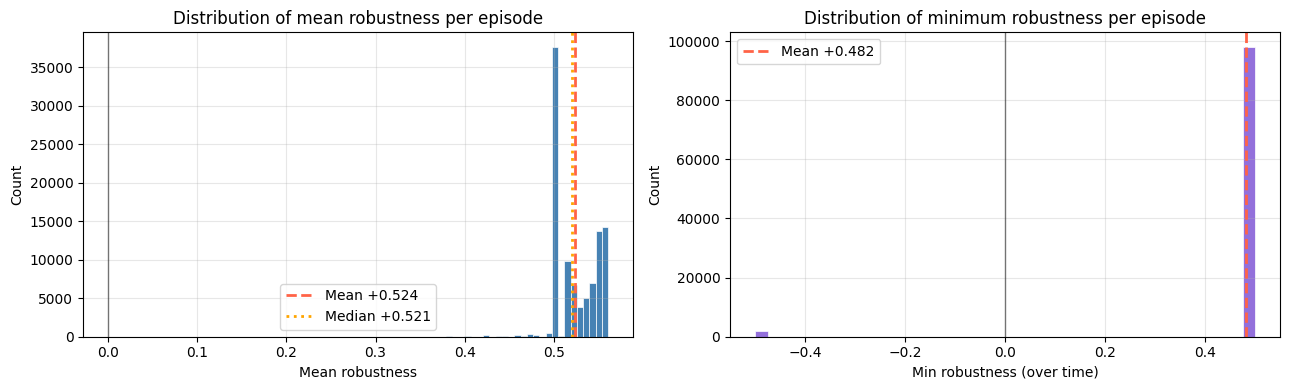

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Mean robustness per episode
ax = axes[0]
ax.hist(mean_rob_np, bins=40, color='steelblue', edgecolor='white', linewidth=0.5)
ax.axvline(mean_rob_np.mean(), color='tomato', lw=2, linestyle='--', label=f'Mean {mean_rob_np.mean():+.3f}')
ax.axvline(np.median(mean_rob_np), color='orange', lw=2, linestyle=':', label=f'Median {np.median(mean_rob_np):+.3f}')
ax.axvline(0, color='black', lw=1, alpha=0.5, linestyle='-')
ax.set_title('Distribution of mean robustness per episode')
ax.set_xlabel('Mean robustness')
ax.set_ylabel('Count')
ax.legend()
ax.grid(alpha=0.3)

# Minimum robustness per episode (worst time-point)
ax = axes[1]
ax.hist(min_rob_np, bins=40, color='mediumpurple', edgecolor='white', linewidth=0.5)
ax.axvline(min_rob_np.mean(), color='tomato', lw=2, linestyle='--', label=f'Mean {min_rob_np.mean():+.3f}')
ax.axvline(0, color='black', lw=1, alpha=0.5, linestyle='-')
ax.set_title('Distribution of minimum robustness per episode')
ax.set_xlabel('Min robustness (over time)')
ax.set_ylabel('Count')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Per-Timestep Robustness Profile

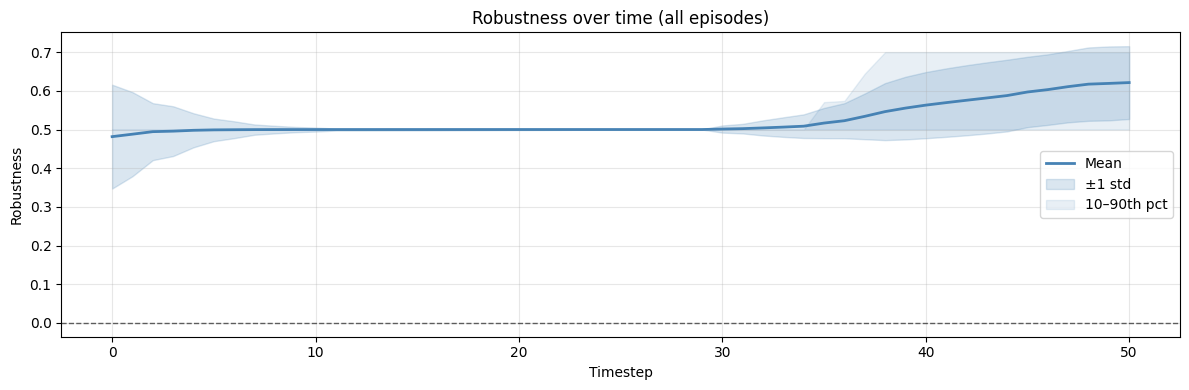

In [8]:
rob_time_np = robs_time.numpy()   # (n_eval_episodes, T+1)
t_axis = np.arange(rob_time_np.shape[1])   # actual length after spec look-ahead

rob_mean = rob_time_np.mean(axis=0)
rob_std  = rob_time_np.std(axis=0)
rob_p10  = np.percentile(rob_time_np, 10, axis=0)
rob_p90  = np.percentile(rob_time_np, 90, axis=0)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t_axis, rob_mean, lw=2, color='steelblue', label='Mean')
ax.fill_between(t_axis, rob_mean - rob_std, rob_mean + rob_std, alpha=0.2, color='steelblue', label='±1 std')
ax.fill_between(t_axis, rob_p10, rob_p90, alpha=0.12, color='steelblue', label='10–90th pct')
ax.axhline(0, color='black', lw=1, alpha=0.6, linestyle='--')
ax.set_title('Robustness over time (all episodes)')
ax.set_xlabel('Timestep')
ax.set_ylabel('Robustness')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Best / Median / Worst Episode Trajectories

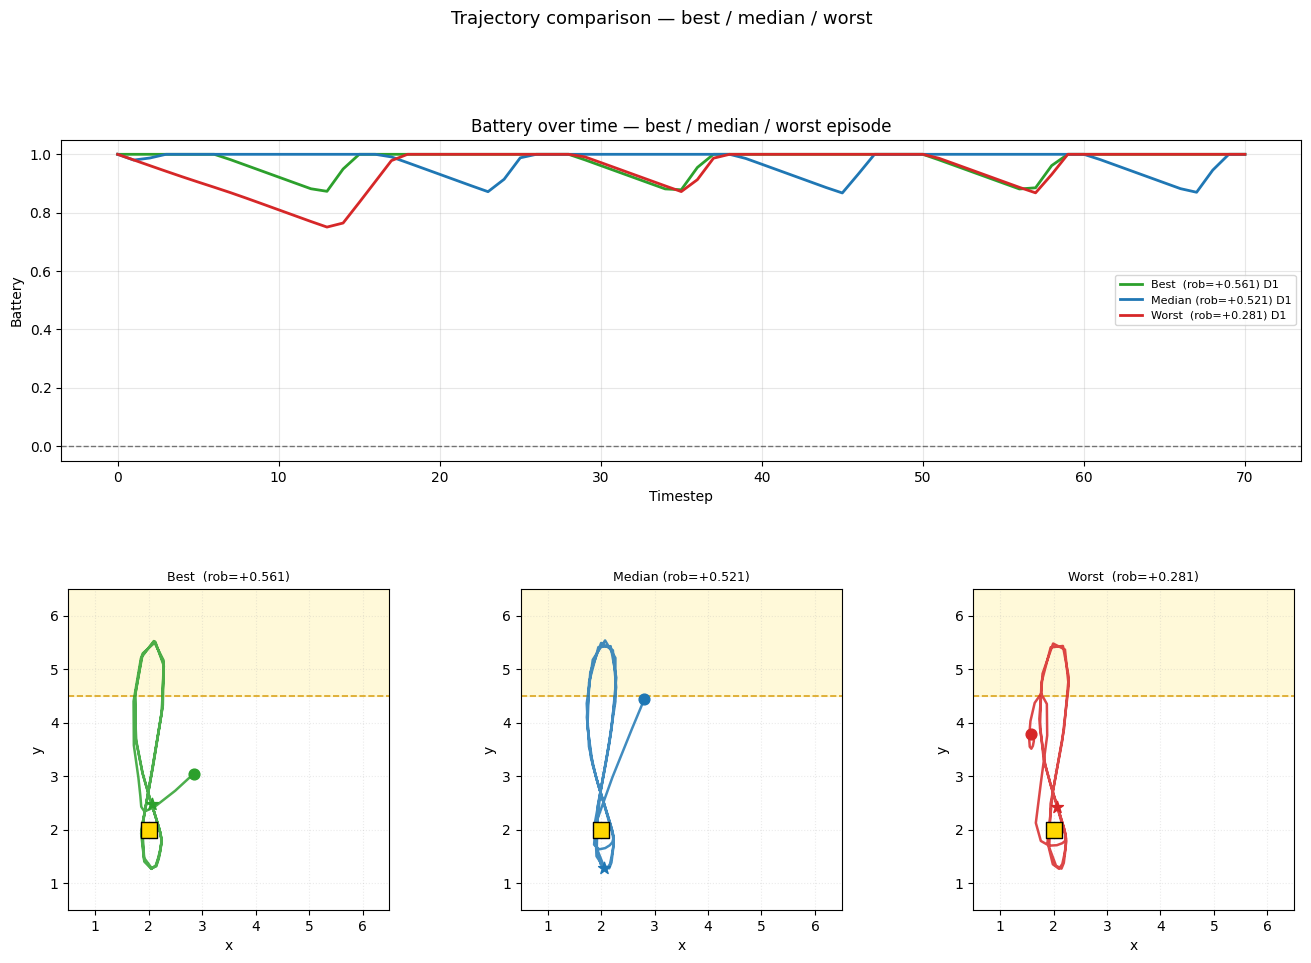

In [9]:
best_idx   = int(mean_robs.argmax())
worst_idx  = int(mean_robs.argmin())
median_idx = int(np.argsort(mean_rob_np)[len(mean_rob_np) // 2])

episodes = {
    f"Best  (rob={mean_rob_np[best_idx]:+.3f})": best_idx,
    f"Median (rob={mean_rob_np[median_idx]:+.3f})": median_idx,
    f"Worst  (rob={mean_rob_np[worst_idx]:+.3f})": worst_idx,
}
colors_ep = ['tab:green', 'tab:blue', 'tab:red']

# states_all: (T+1, n_eval_episodes, n_nodes, n_feat)
def get_traj_np(ep_idx):
    # returns (n_nodes, n_feat, T+1)
    return states_all[:, ep_idx, :, :].permute(1, 2, 0).numpy()

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

ax_batt = fig.add_subplot(gs[0, :])
ax_xy   = [fig.add_subplot(gs[1, i]) for i in range(3)]

t_axis = np.arange(T_total + 1)

for (label, ep_idx), color in zip(episodes.items(), colors_ep):
    data = get_traj_np(ep_idx)   # (n_nodes, n_feat, T+1)
    for d in range(cfg.n_drones):
        drone_node = cfg.drone_slice.start + d
        ax_batt.plot(t_axis, data[drone_node, 4, :], color=color, lw=2, label=f'{label} D{d+1}')

ax_batt.axhline(0, color='black', lw=1, linestyle='--', alpha=0.5)
ax_batt.set_title('Battery over time — best / median / worst episode')
ax_batt.set_xlabel('Timestep')
ax_batt.set_ylabel('Battery')
ax_batt.set_ylim(-0.05, 1.05)
ax_batt.legend(fontsize=8)
ax_batt.grid(alpha=0.3)

base_positions_np = states_all[0, best_idx, cfg.base_slice, 0:2].numpy()

for ax_i, ((label, ep_idx), color) in zip(ax_xy, zip(episodes.items(), colors_ep)):
    data = get_traj_np(ep_idx)
    ax_i.set_xlim(0.5, grid_side + 0.5)
    ax_i.set_ylim(0.5, grid_side + 0.5)
    ax_i.set_aspect('equal')
    ax_i.grid(alpha=0.25, linestyle=':')
    target_y = 0.75 * grid_side
    ax_i.axhspan(target_y, grid_side + 0.5, color='gold', alpha=0.15)
    ax_i.axhline(target_y, color='goldenrod', lw=1.2, linestyle='--')
    # Charging bases
    ax_i.scatter(base_positions_np[:, 0], base_positions_np[:, 1],
                 marker='s', s=120, c='gold', edgecolors='black', zorder=3)
    for d in range(cfg.n_drones):
        drone_node = cfg.drone_slice.start + d
        x_traj = data[drone_node, 0, :]
        y_traj = data[drone_node, 1, :]
        ax_i.plot(x_traj, y_traj, color=color, lw=1.8, alpha=0.85)
        ax_i.scatter(x_traj[0], y_traj[0], color=color, s=60, zorder=4, marker='o')
        ax_i.scatter(x_traj[-1], y_traj[-1], color=color, s=80, zorder=4, marker='*')
    ax_i.set_title(label, fontsize=9)
    ax_i.set_xlabel('x')
    ax_i.set_ylabel('y')

plt.suptitle('Trajectory comparison — best / median / worst', fontsize=13, y=1.01)
plt.show()

## Per-Timestep Robustness for Selected Episodes

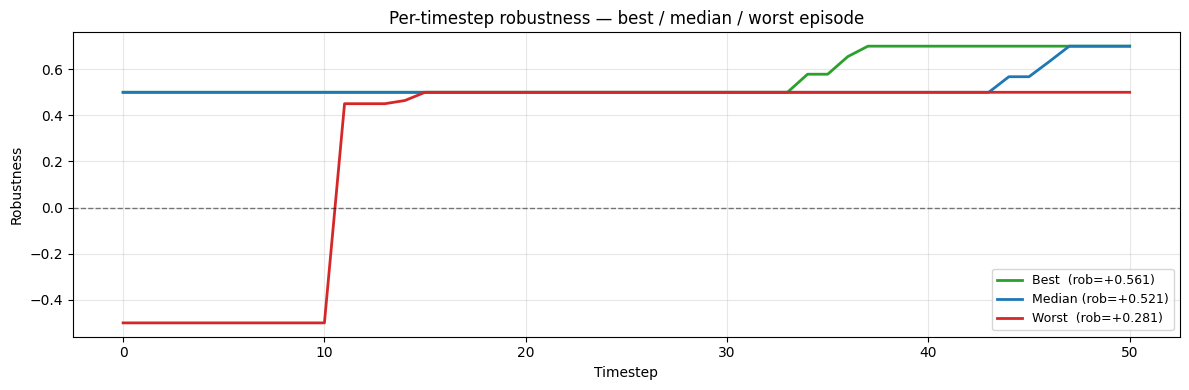

In [10]:
t_axis_rob = np.arange(rob_time_np.shape[1])

fig, ax = plt.subplots(figsize=(12, 4))
for (label, ep_idx), color in zip(episodes.items(), colors_ep):
    ax.plot(t_axis_rob, rob_time_np[ep_idx], color=color, lw=2, label=label)
ax.axhline(0, color='black', lw=1, linestyle='--', alpha=0.5)
ax.set_title('Per-timestep robustness — best / median / worst episode')
ax.set_xlabel('Timestep')
ax.set_ylabel('Robustness')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()